# TP1 - Visión por Computadora

**Integrantes:**
- Julián Barceló
- Jonatan Mild
- Víctor Hugo Astorga
- Manuel Briend
- Valentín Torres

---

**Parte 1:** Algoritmo White Patch para corrección de iluminación.

**Parte 2:** Histogramas en escala de grises.

## Parte 1 - White Patch

El algoritmo **White Patch** (parche blanco) es un método sencillo de *balance de blancos* que asume que el píxel más brillante de la escena corresponde a un objeto blanco iluminado por la misma fuente de luz que el resto de la imagen.

Para cada canal de color (B, G, R en OpenCV) se calcula un percentil alto y se escala el canal de modo que ese valor pase a 255, compensando así las dominantes cromáticas producidas por la iluminación.

In [1]:
%matplotlib inline  
import cv2 as cv
import time
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [2]:
# leer primer imagen
def read_image(image_name):
   # image_path = os.path.join("white_patch", image_name)
    img = cv.imread(image_name, cv.IMREAD_COLOR)
    if img is None:
            print("Image not found.")
    return(img)    


In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


def white_patch_percentiles(
    img,
    percentiles=(98.5, 99, 99.5, 99.9)
):
    """
    Aplica White Patch usando distintos percentiles y muestra
    los resultados junto con la imagen original.

    Parameters
    ----------
    img : np.ndarray
        Imagen en formato BGR, como la devuelve OpenCV.
    percentiles : tuple
        Percentiles que se utilizarán como referencia de blanco.

    Returns
    -------
    resultados : dict
        Diccionario con las imágenes corregidas.
        La clave es el percentil utilizado.
    """

    if img is None:
        raise ValueError("La imagen recibida es None.")

    if img.ndim != 3 or img.shape[2] != 3:
        raise ValueError("La imagen debe tener 3 canales BGR.")

    image_float = img.astype(np.float32)

    resultados = {}
    factores_por_percentil = {}

    for percentile in percentiles:

        # Percentil calculado por separado para los canales B, G y R
        referencia = np.percentile(
            image_float,
            percentile,
            axis=(0, 1)
        )

        # Evita divisiones por cero
        referencia = np.maximum(referencia, 1e-6)

        # Factores BGR
        factores = 255.0 / referencia

        # Aplicación de los factores mediante broadcasting
        corregida = image_float * factores

        # Limita los valores entre 0 y 255
        corregida = np.clip(corregida, 0, 255).astype(np.uint8)

        resultados[percentile] = corregida
        factores_por_percentil[percentile] = factores

    # Cantidad total: imagen original + resultados
    cantidad_imagenes = len(percentiles) + 1

    plt.figure(figsize=(18, 8))

    # Imagen original
    plt.subplot(2, 3, 1)
    plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title("Imagen original")
    plt.axis("off")

    # Imágenes corregidas
    for posicion, percentile in enumerate(percentiles, start=2):

        corregida = resultados[percentile]
        factores = factores_por_percentil[percentile]

        fact_b, fact_g, fact_r = factores

        plt.subplot(2, 3, posicion)
        plt.imshow(cv.cvtColor(corregida, cv.COLOR_BGR2RGB))

        plt.title(
            f"White Patch P{percentile}\n"
            f"B={fact_b:.2f} | G={fact_g:.2f} | R={fact_r:.2f}"
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

    return resultados

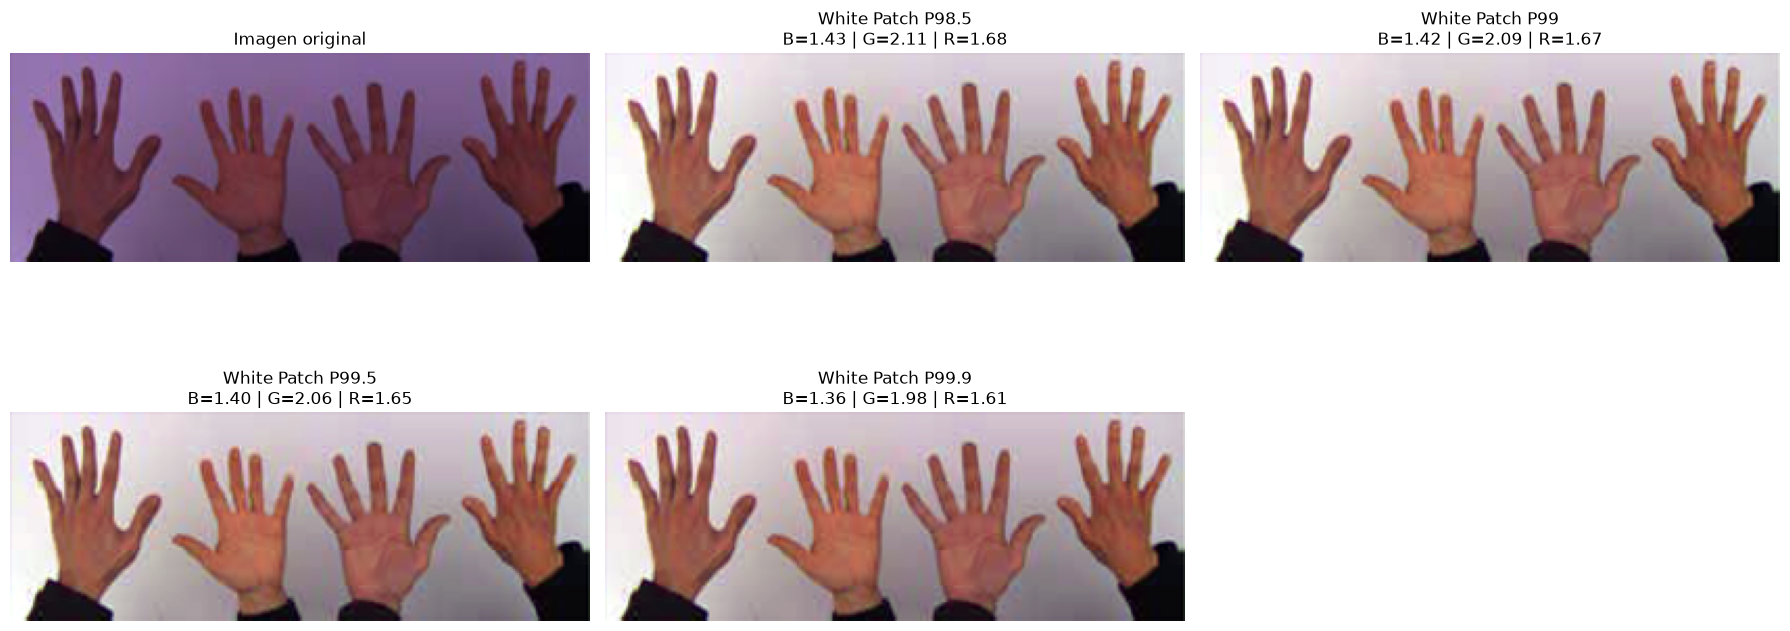

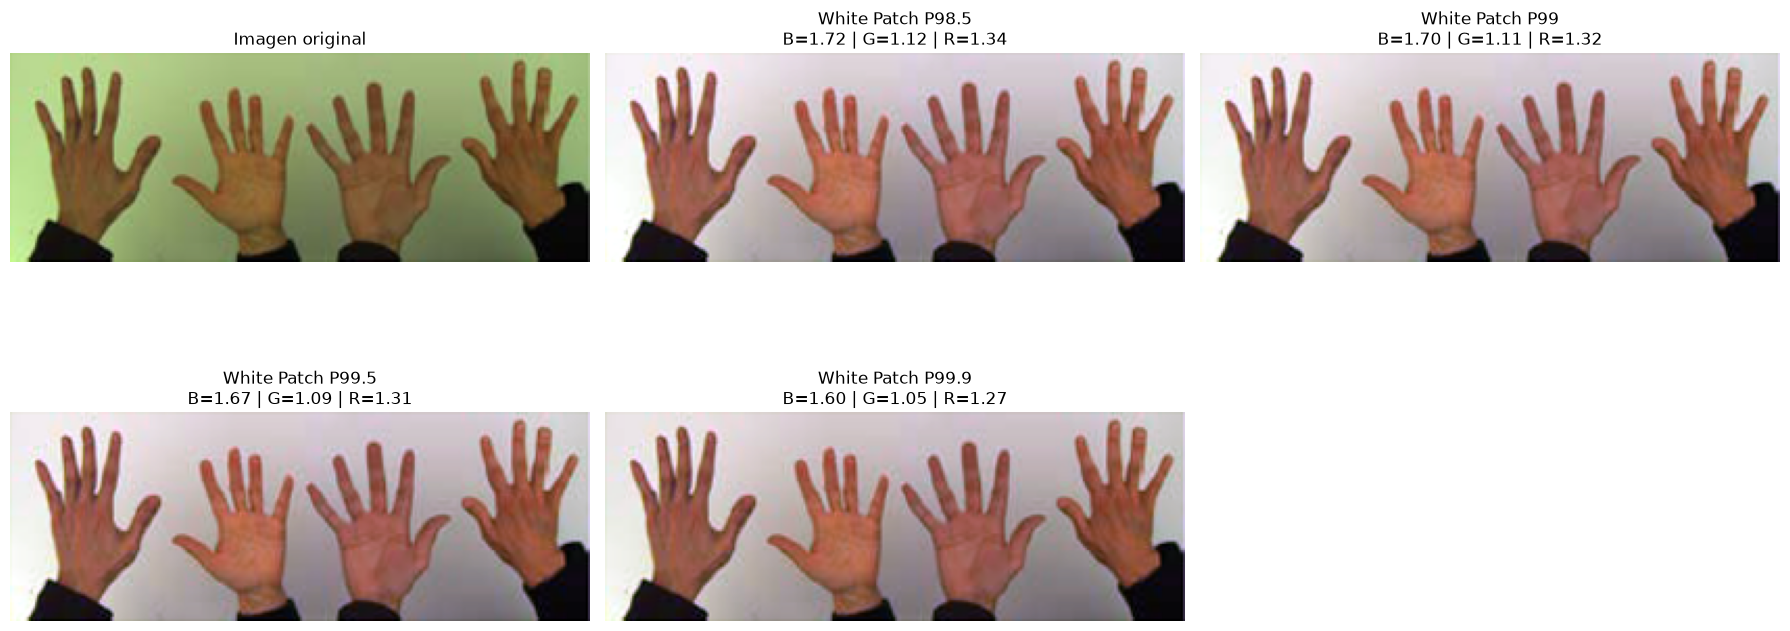

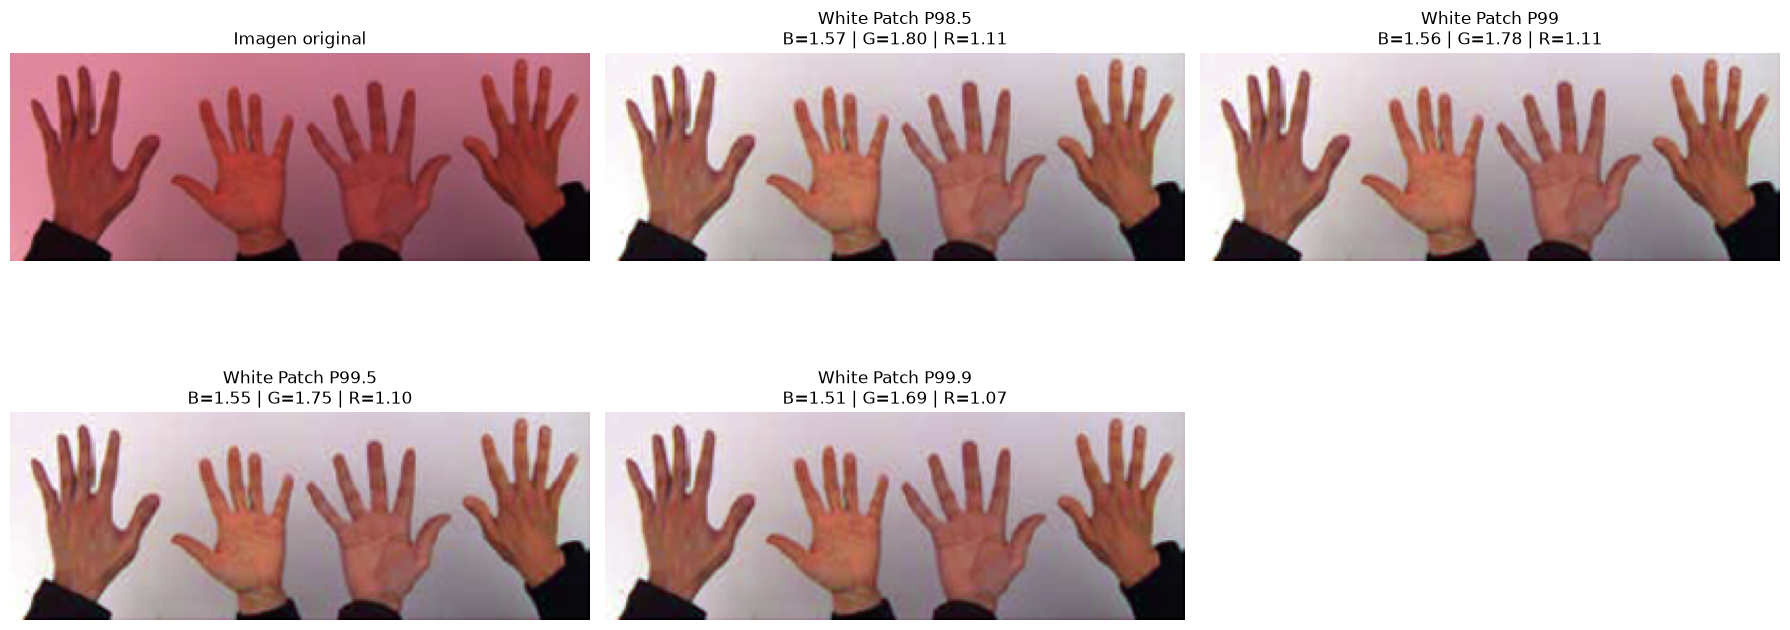

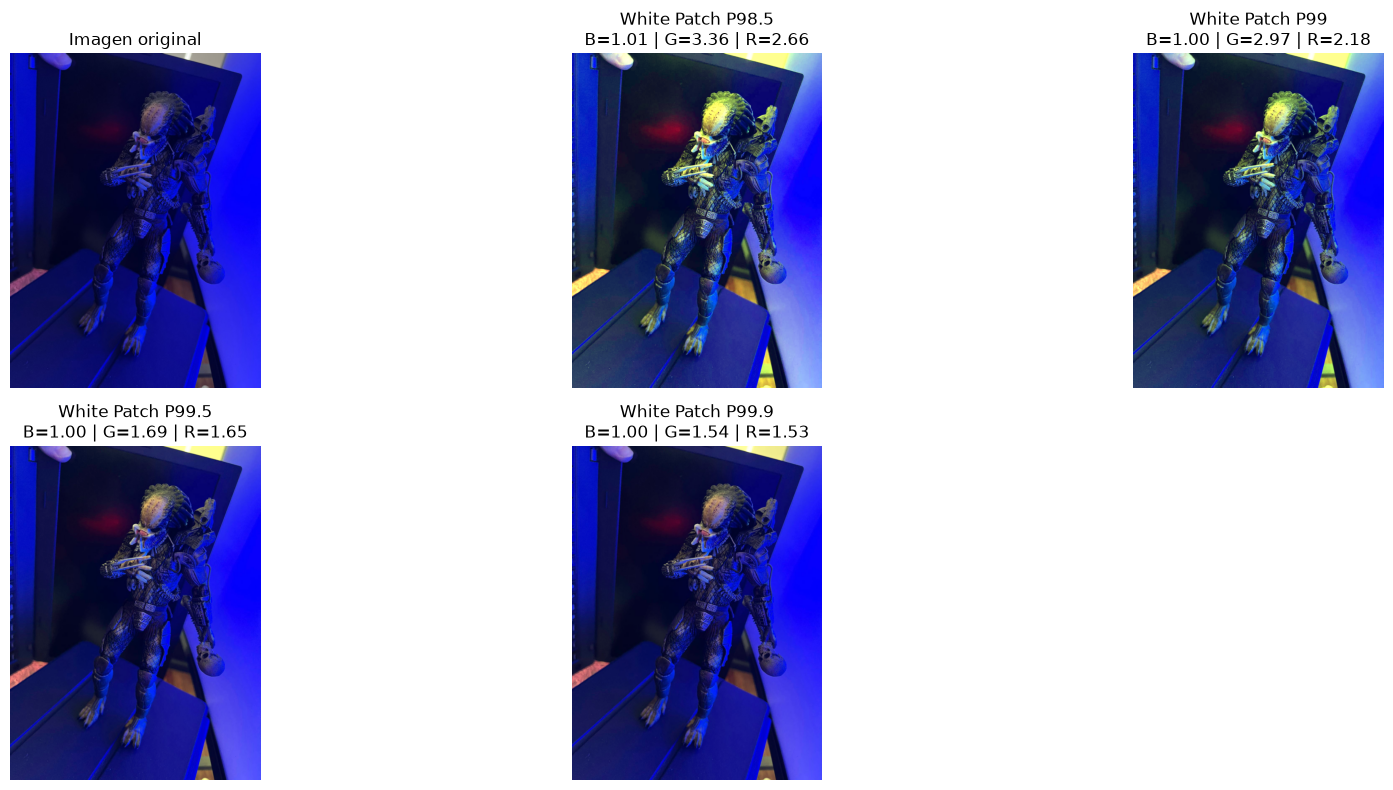

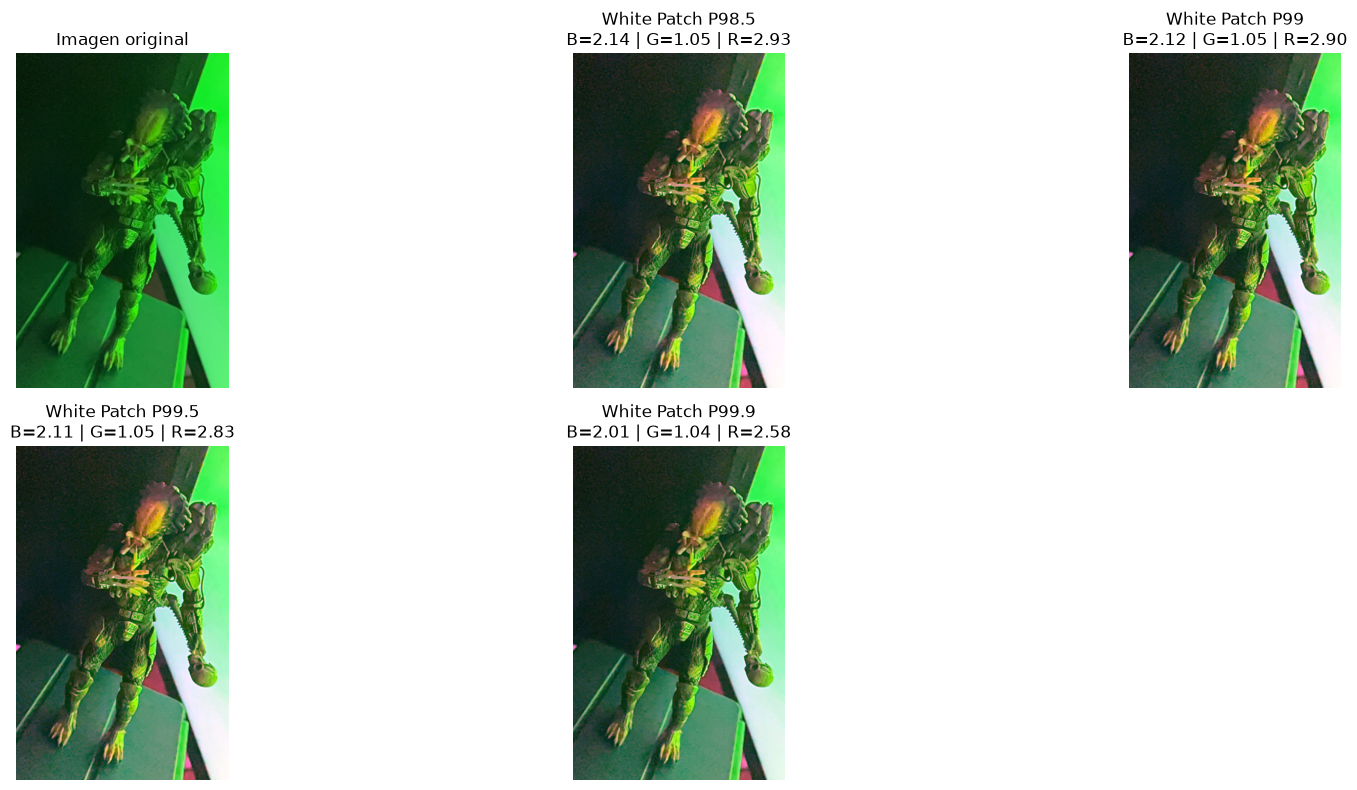

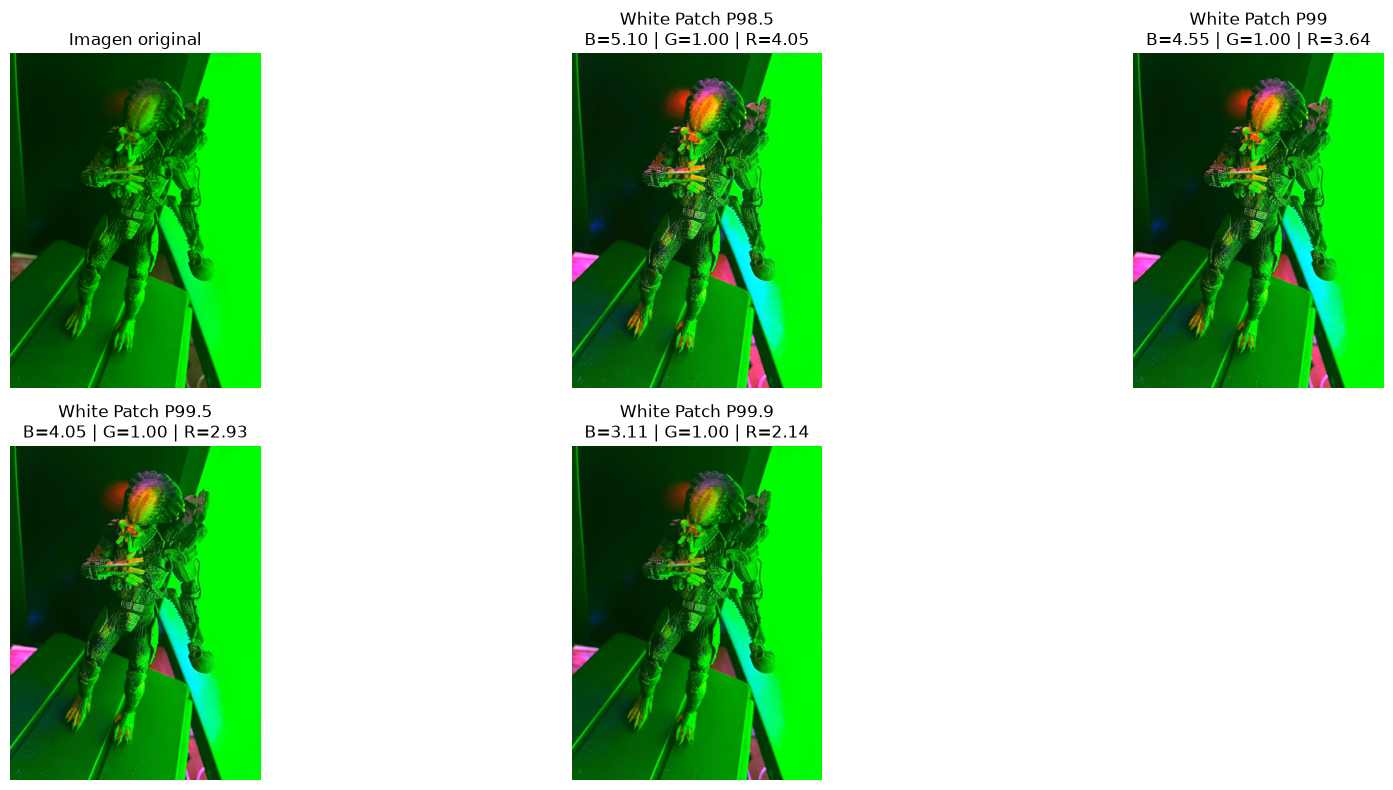

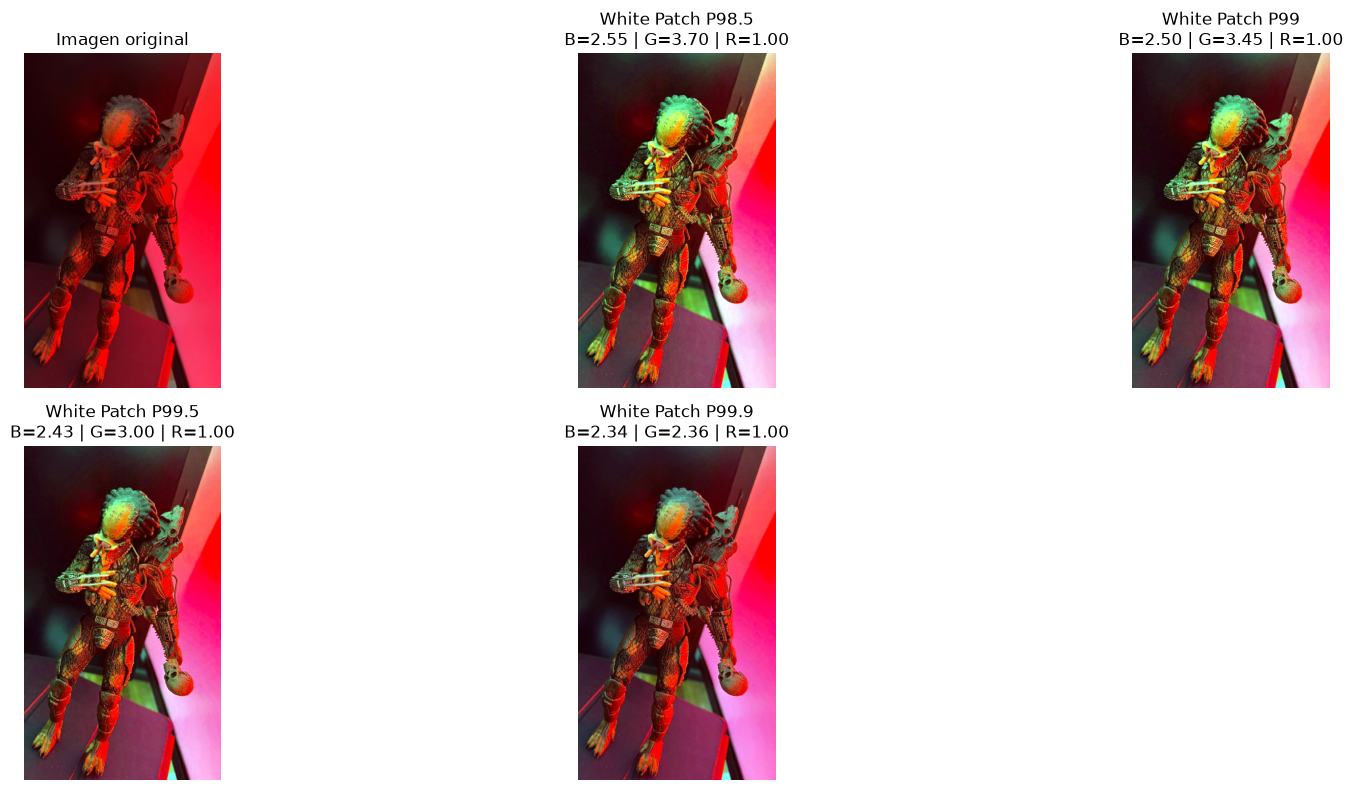

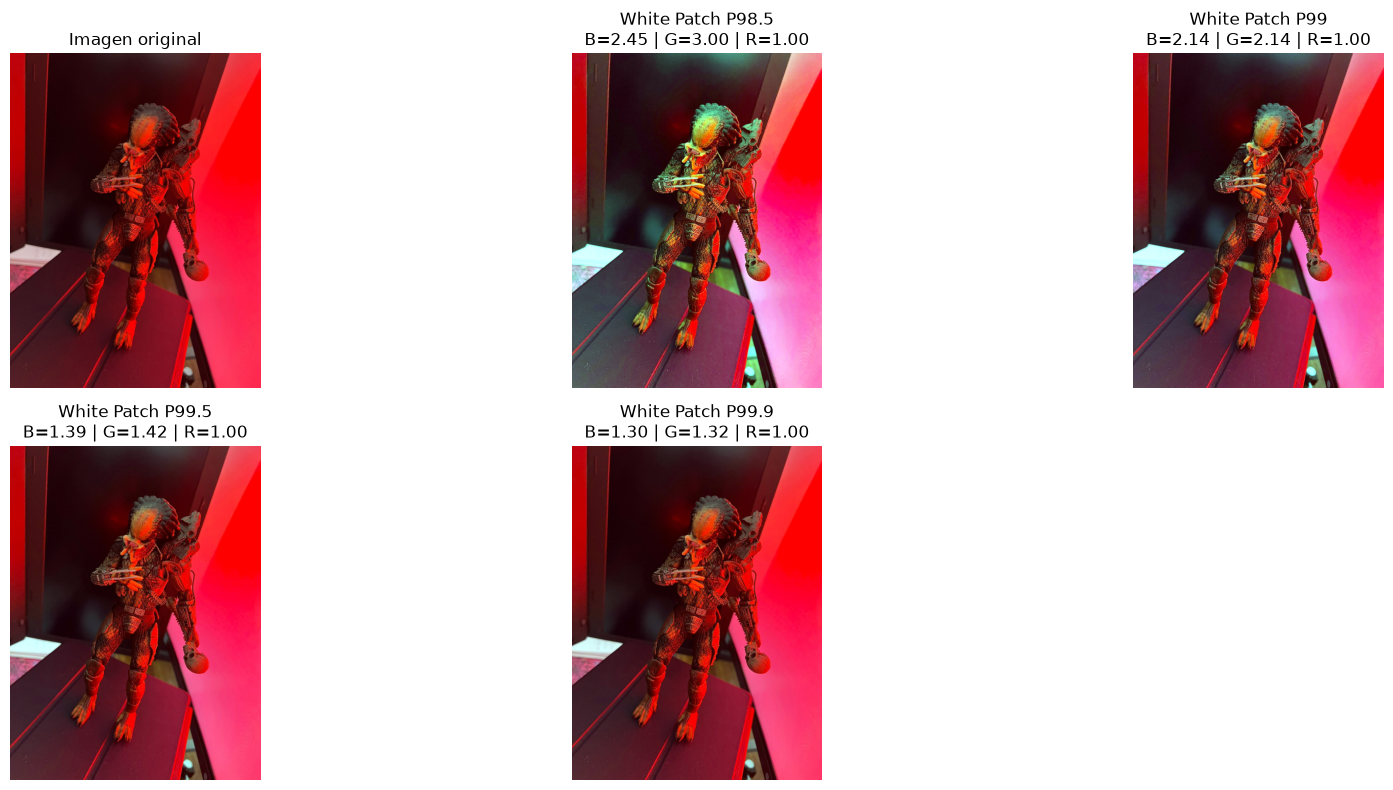

In [4]:
folder = Path("white_patch")
for image_path in folder.iterdir():
    white_patch_percentiles(read_image(image_path))

## Conclusiones:

White Patch corrigió la dominante de color tomando los valores más claros de cada canal como referencia de blanco. Se utilizaron los percentiles 98.5, 99, 99.5 y 99.9 en lugar del máximo absoluto, con el objetivo de reducir el impacto del ruido, los reflejos y los píxeles saturados. A partir de la comparación visual de los resultados, se observó que el percentil 99 produjo la mejor corrección para la imagen analizada.

Sin embargo, según el percentil elegido, pueden saturarse las zonas más claras o perderse detalles. Por lo tanto, aunque White Patch es un método rápido y sencillo, su desempeño depende del contenido de la imagen, de las condiciones de iluminación y del percentil utilizado.

---

## Parte 2 - Histogramas en escala de grises

Se leen `img1_tp.png` e `img2_tp.png` en escala de grises, se calculan sus histogramas y se comparan.

Para imágenes de 8 bits, lo natural es usar **256 bins** en el rango `[0, 256)`, ya que cada bin representa un nivel de gris entero (0-255). Este criterio es el mismo que se utiliza en el material de histogramas del curso (`Material/Codigo/Clase2/01.Brillo.ipynb`).

In [2]:
# leer primer imagen
def read_image_gray(image_name):
   # image_path = os.path.join("white_patch", image_name)
    img = cv.imread(image_name, cv.IMREAD_GRAYSCALE)
    if img is None:
            print("Image not found.")
    return(img)    

In [3]:
# Convertir a float para evitar saturación durante los cálculos
def grey_analysis (img,bins):
    fig, (ax1, ax2) = plt.subplots(1,2)
    ax1.imshow(img, cmap='gray')
    ax1.set_title('imagen') 
    ax1.axis('off')
    hist1,bins1 = np.histogram(img.ravel(),bins,[0,256])
    print("Histogram shape:", hist1.shape)  # (256,)
    print("First 10 bin counts:", hist1[:10])
    print("Bin edges:", bins1[:10])
    ax2.set_title(f'Histograma con {bins} bins') 
    plt.xlabel("Pixel value")
    plt.ylabel("Frequency")
    ax2.plot(hist1)
    fig.tight_layout()
    plt.show()
    return()

Histogram shape: (255,)
First 10 bin counts: [  0   1   1   2   0   0   0   0   0 159]
Bin edges: [0.         1.00392157 2.00784314 3.01176471 4.01568627 5.01960784
 6.02352941 7.02745098 8.03137255 9.03529412]


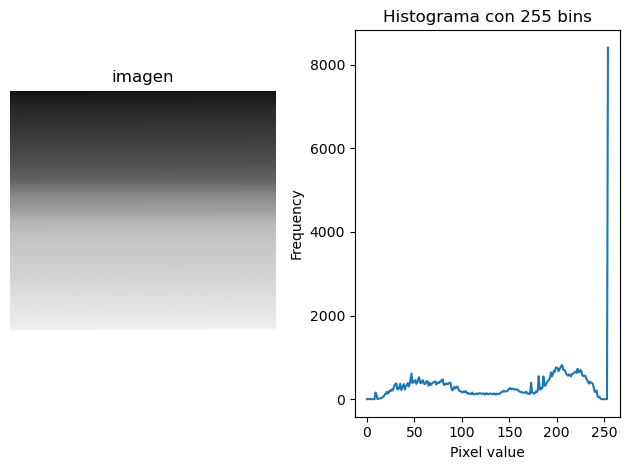

Histogram shape: (255,)
First 10 bin counts: [  0   1   1   2   0   0   0   0   0 159]
Bin edges: [0.         1.00392157 2.00784314 3.01176471 4.01568627 5.01960784
 6.02352941 7.02745098 8.03137255 9.03529412]


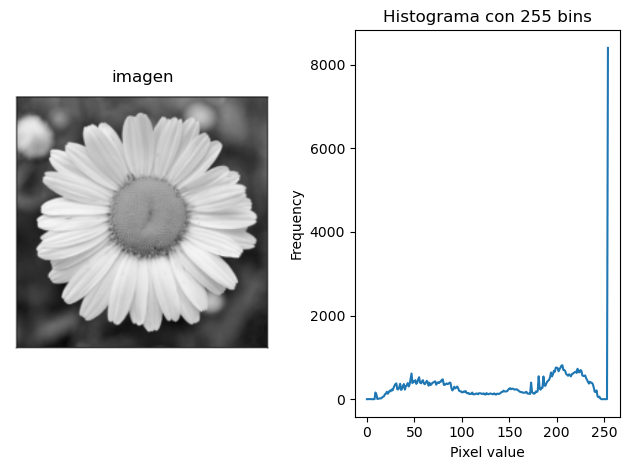

In [4]:
file_list = ['img1_tp.png','img2_tp.png']
for image_path in file_list:
       grey_analysis(read_image_gray(image_path),255)

### Observaciones

Los histogramas en escala de grises de las dos imágenes son iguales, siendo las imágenes totalmente diferentes: `img1_tp.png` es un degradado vertical (oscuro arriba, claro abajo) e `img2_tp.png` es la fotografía de una margarita. La diferencia está en la ubicación espacial de los píxeles, información que el histograma no conserva.

Por lo tanto, los histogramas pueden ser útiles como features para describir luminosidad, contraste o distribución tonal, pero no son suficientes por sí solos para tareas de clasificación o detección en las que sea importante reconocer formas, texturas o la posición de los objetos.